# IndabaX Botswana Hackathon 2026
## Forecasting Botswana's Food Price Inflation Under Global Economic Shocks

### Notebook 04: Deep Learning Model — LSTM

**Purpose:** Builds, trains, and validates a 2-layer LSTM
(hidden size 16, dropout 0.4) on forecast-safe features using
direct multi-output forecasting (6-month lookback, 12-month
horizon). Random seed fixed (42) for reproducibility. Compares
against the SARIMAX baseline and naive forecast. Generates the
final Jan–Dec 2024 forecast used in the Predictions CSV.

**Input:** `data/processed/modelling_table_with_lags.csv`
**Output:** `outputs/predictions.csv`, model weights in `outputs/models/`,
figures in `outputs/figures/`

In [65]:
# ── Imports ──
import pandas as pd
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# seed for reproducability
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [66]:
# load data
df_with_lags = pd.read_csv('../data/processed/modelling_table_with_lags.csv')
df_with_lags['year_month'] = pd.to_datetime(df_with_lags['year_month'])


In [67]:
# ── Forecast-safe exogenous features (lag12 only, resolve to known 2023-or-earlier data) ──
exog_cols_safe = [
    'target_food_price_inflation_lag12',
    'hcp_zaf_fao_cp_23014_lag12',
    'brent_yoy_pct_lag12',
    'brent_usd_per_barrel_lag12',
    'policy_rate_lag12',
    'bdi_close_mean_lag12',
    'month_sin', 'month_cos'
]

selected_cols_safe = ['year_month', 'target_food_price_inflation'] + exog_cols_safe
model_df_safe = df_with_lags[selected_cols_safe].dropna().reset_index(drop=True)
print('model_df_safe shape:', model_df_safe.shape)


model_df_safe shape: (264, 10)


In [68]:
# chronological split
train = model_df_safe[model_df_safe['year_month'] <= '2020-12-01'].reset_index(drop=True)
val = model_df_safe[(model_df_safe['year_month'] > '2020-12-01') & (model_df_safe['year_month'] <= '2022-12-01')].reset_index(drop=True)

feature_cols = exog_cols_safe
target_col = 'target_food_price_inflation'

In [69]:
# standardizing (fit on train only)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(train[feature_cols])
X_val_scaled = scaler_X.transform(val[feature_cols])

y_train_scaled = scaler_y.fit_transform(train[[target_col]])
y_val_scaled = scaler_y.transform(val[[target_col]])


In [70]:
# building sliding window sequences with 6 months lookback
def create_multistep_sequences(X, y, lookback=6, horizon=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback - horizon + 1):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i+lookback : i+lookback+horizon])  # 12 future values, not 1
    return np.array(X_seq), np.array(y_seq)
    
lookback=6
horizon = 12

X_train_seq, y_train_seq = create_multistep_sequences(X_train_scaled, y_train_scaled, lookback, horizon)
X_val_seq, y_val_seq = create_multistep_sequences(X_val_scaled, y_val_scaled, lookback, horizon)

print(X_train_seq.shape, y_train_seq.shape)
print(X_val_seq.shape, y_val_seq.shape)

(211, 6, 8) (211, 12, 1)
(7, 6, 8) (7, 12, 1)


In [71]:
# fixing the shape
y_train_seq = y_train_seq.squeeze(-1)  # (211, 12, 1) -> (211, 12)
y_val_seq = y_val_seq.squeeze(-1)      # (19, 12, 1) -> (19, 12)
print(y_train_seq.shape, y_val_seq.shape)

# converting to pytorch tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_val_tensor.shape, y_val_tensor.shape)

(211, 12) (7, 12)
torch.Size([211, 6, 8]) torch.Size([211, 12])
torch.Size([7, 6, 8]) torch.Size([7, 12])


## V1 Model - FoodInflationLSTM(
  (lstm): LSTM(8, 32, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=32, out_features=12, bias=True)
)

In [72]:
# model architecture
class FoodInflationLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=2, dropout=0.3, horizon=12):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers,
                             dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, horizon)  # 12 outputs

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

model = FoodInflationLSTM(n_features=X_train_tensor.shape[2], hidden_size=32, num_layers=2, dropout=0.3, horizon=12)
print(model)

FoodInflationLSTM(
  (lstm): LSTM(8, 32, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=32, out_features=12, bias=True)
)


In [73]:
# training loop
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

n_epochs = 200
patience = 20
best_val_loss = float('inf')
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    model.eval()
    with torch.no_grad():
        val_output = model(X_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)

    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_lstm.pth')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

    if epoch % 20 == 0:
        print(f'Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={val_loss.item():.4f}')


Epoch 0: train_loss=1.0230, val_loss=0.6705
Early stopping at epoch 20


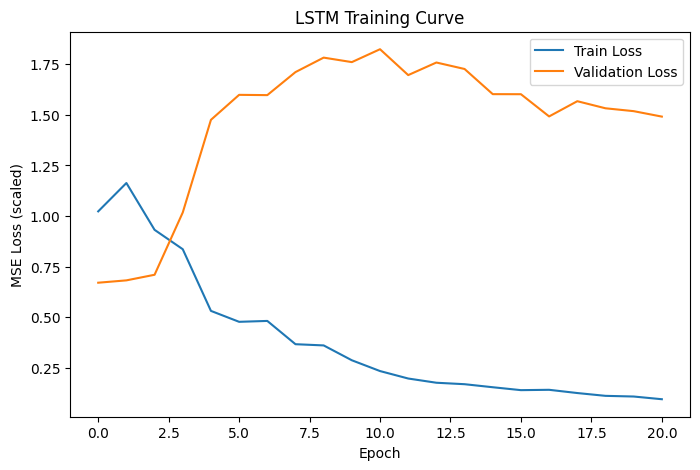

In [74]:
# training vs validation loss curve 
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (scaled)')
plt.title('LSTM Training Curve')
plt.legend()

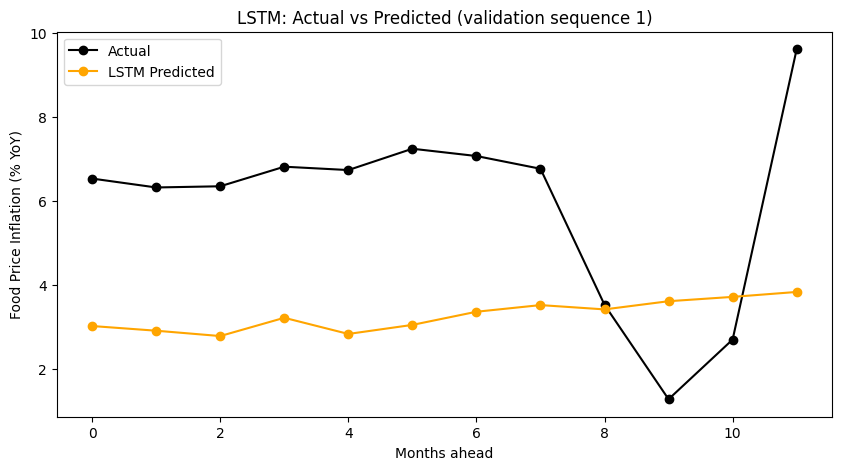

In [75]:
# actual vs predicted graph 
model.eval()
with torch.no_grad():
    val_pred_scaled = model(X_val_tensor).numpy()

# inverse transform back to real inflation % scale
val_pred = scaler_y.inverse_transform(val_pred_scaled)
val_actual = scaler_y.inverse_transform(y_val_tensor.numpy())

# plot just the first validation sequence's 12-month forecast as an example
plt.figure(figsize=(10,5))
plt.plot(range(12), val_actual[0], label='Actual', color='black', marker='o')
plt.plot(range(12), val_pred[0], label='LSTM Predicted', color='orange', marker='o')
plt.xlabel('Months ahead')
plt.ylabel('Food Price Inflation (% YoY)')
plt.title('LSTM: Actual vs Predicted (validation sequence 1)')
plt.legend()


In [76]:
# load best model and evaluate on validation
model.load_state_dict(torch.load('best_lstm.pth'))
model.eval()
with torch.no_grad():
    val_pred_scaled = model(X_val_tensor).numpy()

val_pred = scaler_y.inverse_transform(val_pred_scaled)
val_actual = scaler_y.inverse_transform(y_val_tensor.numpy())

lstm_rmse = np.sqrt(mean_squared_error(val_actual, val_pred))
lstm_mae = mean_absolute_error(val_actual, val_pred)
print('LSTM (safe features) RMSE:', lstm_rmse, 'MAE:', lstm_mae)

LSTM (safe features) RMSE: 4.457838060671439 MAE: 3.3986318111419678


# V2 Model - FoodInflationLSTM_v2(
  (lstm): LSTM(8, 16, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=16, out_features=12, bias=True)
)


In [77]:
# model with smaller architecture
class FoodInflationLSTM_v2(nn.Module):
    def __init__(self, n_features, hidden_size=16, num_layers=2, dropout=0.4, horizon=12):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers,
                             dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

model_v2 = FoodInflationLSTM_v2(n_features=X_train_tensor.shape[2], hidden_size=16, num_layers=2, dropout=0.4, horizon=12)
print(model_v2)

criterion = nn.MSELoss()
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=0.0005, weight_decay=1e-4)  # lower LR, stronger weight decay

n_epochs = 200
patience = 20
best_val_loss = float('inf')
epochs_no_improve = 0
train_losses_v2, val_losses_v2 = [], []

for epoch in range(n_epochs):
    model_v2.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer_v2.zero_grad()
        output = model_v2(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer_v2.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    model_v2.eval()
    with torch.no_grad():
        val_output = model_v2(X_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)

    train_losses_v2.append(epoch_train_loss)
    val_losses_v2.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        epochs_no_improve = 0
        torch.save(model_v2.state_dict(), 'best_lstm_v2.pth')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

    if epoch % 20 == 0:
        print(f'Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={val_loss.item():.4f}')



FoodInflationLSTM_v2(
  (lstm): LSTM(8, 16, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=16, out_features=12, bias=True)
)
Epoch 0: train_loss=1.0421, val_loss=0.6065
Early stopping at epoch 20


LSTM v2 (smaller, more regularized) RMSE: 4.239886648714245 MAE: 3.292245626449585


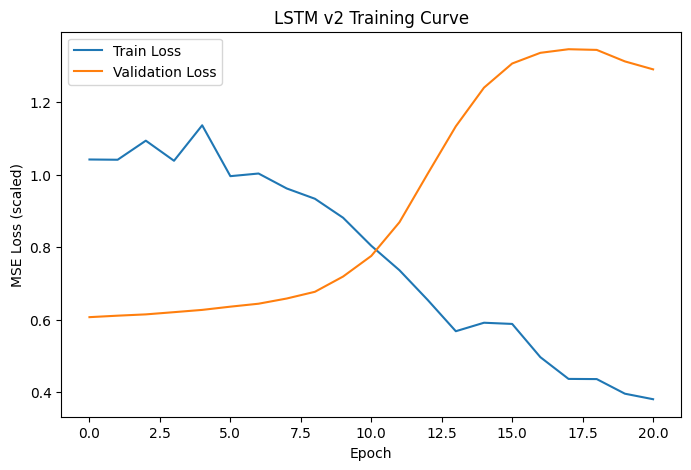

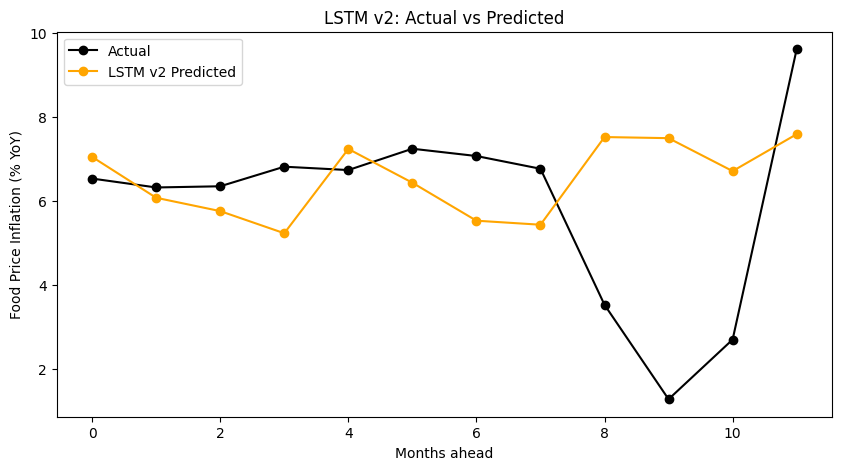

In [78]:
# version2 model plots
model_v2.load_state_dict(torch.load('best_lstm_v2.pth'))
model_v2.eval()
with torch.no_grad():
    val_pred_scaled_v2 = model_v2(X_val_tensor).numpy()

val_pred_v2 = scaler_y.inverse_transform(val_pred_scaled_v2)
val_actual_v2 = scaler_y.inverse_transform(y_val_tensor.numpy())

lstm_rmse_v2 = np.sqrt(mean_squared_error(val_actual_v2, val_pred_v2))
lstm_mae_v2 = mean_absolute_error(val_actual_v2, val_pred_v2)
print('LSTM v2 (smaller, more regularized) RMSE:', lstm_rmse_v2, 'MAE:', lstm_mae_v2)

plt.figure(figsize=(8,5))
plt.plot(train_losses_v2, label='Train Loss')
plt.plot(val_losses_v2, label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (scaled)')
plt.title('LSTM v2 Training Curve')
plt.legend()
plt.savefig('../outputs/figures/lstm_training_curve.png', dpi=150, bbox_inches='tight')

plt.figure(figsize=(10,5))
plt.plot(range(12), val_actual_v2[0], label='Actual', color='black', marker='o')
plt.plot(range(12), val_pred_v2[0], label='LSTM v2 Predicted', color='orange', marker='o')
plt.xlabel('Months ahead'); plt.ylabel('Food Price Inflation (% YoY)')
plt.title('LSTM v2: Actual vs Predicted')
plt.legend()
plt.savefig('../outputs/figures/lstm_actual_vs_predicted.png', dpi=150, bbox_inches='tight')



In [79]:
# real Jan-Dec 2024 forcast now usiing LSTM v2
# Combine train + val for final training (all data through Dec 2023)
full_data = model_df_safe[model_df_safe['year_month'] <= '2023-12-01'].reset_index(drop=True)

X_full_scaled = scaler_X.fit_transform(full_data[feature_cols])  # refit scaler on ALL data
y_full_scaled = scaler_y.fit_transform(full_data[[target_col]])

# Need the last 6 months (lookback window) to generate the single 2024 forecast sequence
X_final_input = X_full_scaled[-lookback:]  # last 6 months of 2023
X_final_tensor = torch.tensor(X_final_input, dtype=torch.float32).unsqueeze(0)  # add batch dimension

print(X_final_tensor.shape)  # should be (1, 6, 8)


torch.Size([1, 6, 8])


In [80]:
# Retrain LSTM v2 architecture on ALL data through Dec 2023
def create_multistep_sequences(X, y, lookback=6, horizon=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback - horizon + 1):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i+lookback : i+lookback+horizon])
    return np.array(X_seq), np.array(y_seq)

X_full_seq, y_full_seq = create_multistep_sequences(X_full_scaled, y_full_scaled, lookback=6, horizon=12)
y_full_seq = y_full_seq.squeeze(-1)

X_full_tensor = torch.tensor(X_full_seq, dtype=torch.float32)
y_full_tensor = torch.tensor(y_full_seq, dtype=torch.float32)

print(X_full_tensor.shape, y_full_tensor.shape)

# New model instance, same architecture as v2
final_model = FoodInflationLSTM_v2(n_features=X_full_tensor.shape[2], hidden_size=16, num_layers=2, dropout=0.4, horizon=12)

criterion = nn.MSELoss()
optimizer_final = optim.Adam(final_model.parameters(), lr=0.0005, weight_decay=1e-4)

full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=16, shuffle=True)

# Train for the same number of epochs v2 stopped at (25), since we don't have a separate val set to early-stop against here
n_epochs_final = 25

for epoch in range(n_epochs_final):
    final_model.train()
    epoch_loss = 0
    for X_batch, y_batch in full_loader:
        optimizer_final.zero_grad()
        output = final_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer_final.step()
        epoch_loss += loss.item()
    if epoch % 5 == 0:
        print(f'Epoch {epoch}: loss={epoch_loss/len(full_loader):.4f}')

# Generate the actual 2024 forecast
final_model.eval()
with torch.no_grad():
    forecast_2024_scaled = final_model(X_final_tensor).numpy()

forecast_2024 = scaler_y.inverse_transform(forecast_2024_scaled).flatten()

# Build the submission dataframe in the exact required format
year_months = pd.date_range('2024-01', '2024-12', freq='MS').strftime('%Y-%m')

predictions_df = pd.DataFrame({
    'year_month': year_months,
    'forecast': [round(v, 2) for v in forecast_2024]
})

print(predictions_df)

# Save to your outputs folder
predictions_df.to_csv('../outputs/predictions.csv', index=False)
print('Saved to ../outputs/predictions.csv')



torch.Size([247, 6, 8]) torch.Size([247, 12])
Epoch 0: loss=1.0635
Epoch 5: loss=0.9373
Epoch 10: loss=0.6037
Epoch 15: loss=0.4628
Epoch 20: loss=0.4113
   year_month  forecast
0     2024-01      4.93
1     2024-02      5.23
2     2024-03      5.60
3     2024-04      3.84
4     2024-05      4.09
5     2024-06      4.54
6     2024-07      4.24
7     2024-08      3.14
8     2024-09      3.46
9     2024-10      5.28
10    2024-11      3.65
11    2024-12      3.66
Saved to ../outputs/predictions.csv
